# Asteroid Classification for Planetary Defence Using Big Data Analytics

## Introduction

The aim of this project is to carry out exploratory data analysis on an asteroid data set to explore any factors which could indicate that an asteroid may be classified as Potentially Hazardous.

I chose to work on this particular topic as asteroid detection is important for planetary science and safety and ties in with the idea of planetary defence, while also being well-suited for Big Data Analytics as space data sets are typically large and complex, and contain a large number of quantitative features which may be analysed using Python.

---

## Why This Data Set Was Chosen

The NASA/Kaggle asteroid data set was selected as it contains a significant amount of information on asteroids, including the following features:

- asteroid name
- near-Earth object
- Potentially Hazardous Asteroid
- magnitude
- diameter
- orbital data
- further features relevant for asteroid science

These features enable a broad range of tasks to be completed on the data, including data cleaning and preparation, visualisation, feature selection, classification, and model evaluation.

The data set also meets all of the key requirements of the assignment:

- preparation of data using Pandas and NumPy
- check for missing values and duplicates, find any outliers
- visualise patterns and relationships in the data
- classification of Potentially Hazardous and non-Potentially Hazardous asteroids
- evaluation using accuracy, precision, recall, F1-score, confusion matrix

## Dataset Source

The dataset used in this project is the **NASA/Kaggle Asteroid Dataset**.

**Dataset reference:**  
[Asteroid Dataset on Kaggle](https://www.kaggle.com/datasets/sakhawat18/asteroid-dataset)

The dataset contains asteroid-related features such as asteroid name, near-Earth object status, Potentially Hazardous Asteroid status, magnitude, diameter, and orbital characteristics. This source was selected because it provides a large scientific dataset suitable for data cleaning, visualisation, and classification tasks.

# Table of Contents

---

# Part 1 — Data Preparation, Exploration, and Visualisation

1. Project Introduction  
2. Dataset Source  
3. Load the Dataset  
4. Check Dataset Size  
5. Display Dataset Information  
6. Display Column Names  
7. Check Missing Values  
8. Check Duplicate Records  
9. Check Target Column: PHA Status  
10. Check PHA Class Balance  
11. Clean the Target Column  
12. Check Missing Values After Target Cleaning  
13. Check Missing Value Percentage  
14. Remove Columns with Too Many Missing Values  
15. Remove Remaining Missing Values  
16. Confirm Dataset is Fully Clean  
17. Feature Selection  
18. Generate Descriptive Statistics  
19. Visualise PHA Distribution  
20. Visualise Absolute Magnitude  
21. Detect Outliers Using a Boxplot  
22. Create Correlation Heatmap  
23. Compare Hazardous and Non-Hazardous Asteroids  
24. Compare Orbital Eccentricity by PHA Status  
25. Scatter Plot of Semi-Major Axis and Eccentricity  

---

# Part 2 — Machine Learning and Asteroid Classification

26. Prepare Data for Machine Learning  
27. Encode Categorical Variables  
28. Recreate Features and Target After Encoding  
29. Split Training and Testing Data  
30. Train Classification Model  
31. Make Predictions  
32. Evaluate Model Accuracy  
33. Generate Classification Report  
34. Create Confusion Matrix  
35. Analyse Machine Learning Results  
36. Feature Importance Analysis  
37. Visualise Feature Importance  

---

# Part 3 — Conclusion and Final Findings

38. Final Findings Summary  
39. Project Conclusion  
40. Project Limitations  
41. Future Improvements  
42. Final Reflection  

# Part 1 — Data Preparation, Exploration, and Visualisation

This section focuses on loading, cleaning, preparing, and exploring the asteroid dataset using Python and Big Data Analytics techniques.

The analysis includes dataset inspection, handling missing values, duplicate checking, feature selection, descriptive statistics, outlier analysis, correlation analysis, and data visualisation. These steps help prepare the dataset for machine learning and provide a better understanding of asteroid characteristics and patterns.

## 1. Import Python Libraries

This step imports the Python libraries needed for the project.

Pandas and NumPy are used for working with the dataset.  
Matplotlib and Seaborn are used to create charts.  
Scikit-learn is used later to build and test the classification model.
    

In [49]:
# Pandas to be installed/PIP update newer version - if required (needs uncommenting)

#   %pip install pandas numpy matplotlib seaborn scikit-learn
#   %pip install --upgrade pip

In [50]:
# Import libraries for data analysis, charts, and machine learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load the Dataset

This step loads the asteroid CSV file into Python using Pandas.

The dataset is loaded into a DataFrame called `df`. This makes it easier to inspect, clean, and analyse the data.

In [51]:
# Load the asteroid dataset

df = pd.read_csv("Asteroid_Big_Dataset.csv")

# Show the first five rows
df.head()

C:\Users\usaod\AppData\Local\Temp\ipykernel_12448\1567527302.py:3: DtypeWarning: Columns (0: pdes, 1: name, 2: prefix) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Asteroid_Big_Dataset.csv")


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.40,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.20,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.33,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.00,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.90,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191


### Comment

The dataset has loaded successfully. The first five rows show that the file contains asteroid information such as ID, name, near-Earth object status, PHA status, magnitude, diameter, and orbital features.

A warning appeared because some columns have mixed data types. This is not a major problem at this stage, but it shows that the data needs to be inspected and cleaned before analysis.

## 3. Check Dataset Size

This step checks how many rows and columns are in the dataset.

This is useful because it gives a quick idea of the dataset size before cleaning and analysis.

In [52]:
# Check the number of rows and columns in the dataset

df.shape

(958524, 45)

### Comment

The dataset contains 958,524 rows and 45 columns. This confirms that the dataset is large and suitable for Big Data Analytics. It also gives enough features to support cleaning, visualisation, and classification.

## 4. Inspect Dataset Structure and Data Types

This step checks the column names, data types, and non-null values in the dataset.

This is important because before cleaning the data, it is necessary to understand which columns are numerical, which are text-based, and which columns may contain missing values.

In [53]:
# Check dataset structure, column types, and non-null values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 958524 entries, 0 to 958523
Data columns (total 45 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              958524 non-null  str    
 1   spkid           958524 non-null  int64  
 2   full_name       958524 non-null  str    
 3   pdes            958524 non-null  object 
 4   name            22064 non-null   str    
 5   prefix          18 non-null      str    
 6   neo             958520 non-null  str    
 7   pha             938603 non-null  str    
 8   H               952261 non-null  float64
 9   diameter        136209 non-null  float64
 10  albedo          135103 non-null  float64
 11  diameter_sigma  136081 non-null  float64
 12  orbit_id        958524 non-null  str    
 13  epoch           958524 non-null  float64
 14  epoch_mjd       958524 non-null  int64  
 15  epoch_cal       958524 non-null  float64
 16  equinox         958524 non-null  str    
 17  e               95852

### Comment

The dataset structure shows the column names, data types, and how many non-null values each column has. This helps identify which columns may need cleaning and which columns can be used for numerical analysis and machine learning.

## 5. Display Column Names

This step displays all column names in the dataset.

This helps identify useful columns for analysis, such as the PHA target column and asteroid features that may support classification.

In [54]:
# Display all column names

df.columns

Index(['id', 'spkid', 'full_name', 'pdes', 'name', 'prefix', 'neo', 'pha', 'H',
       'diameter', 'albedo', 'diameter_sigma', 'orbit_id', 'epoch',
       'epoch_mjd', 'epoch_cal', 'equinox', 'e', 'a', 'q', 'i', 'om', 'w',
       'ma', 'ad', 'n', 'tp', 'tp_cal', 'per', 'per_y', 'moid', 'moid_ld',
       'sigma_e', 'sigma_a', 'sigma_q', 'sigma_i', 'sigma_om', 'sigma_w',
       'sigma_ma', 'sigma_ad', 'sigma_n', 'sigma_tp', 'sigma_per', 'class',
       'rms'],
      dtype='str')

### Comment

The output shows all available columns in the dataset. This is useful because the next steps will require choosing relevant columns for cleaning, visualisation, and classification.

## 6. Check Data Types

This step checks the data type of each column.

This is useful because some columns are numbers and some are text. For analysis and machine learning, numerical columns are easier to use, while text columns may need cleaning or encoding.

In [55]:
# Check data types of all columns

df.dtypes

id                    str
spkid               int64
full_name             str
pdes               object
name                  str
prefix                str
neo                   str
pha                   str
H                 float64
diameter          float64
albedo            float64
diameter_sigma    float64
orbit_id              str
epoch             float64
epoch_mjd           int64
epoch_cal         float64
equinox               str
e                 float64
a                 float64
q                 float64
i                 float64
om                float64
w                 float64
ma                float64
ad                float64
n                 float64
tp                float64
tp_cal            float64
per               float64
per_y             float64
moid              float64
moid_ld           float64
sigma_e           float64
sigma_a           float64
sigma_q           float64
sigma_i           float64
sigma_om          float64
sigma_w           float64
sigma_ma    

### Comment

The output shows the data type of each column. This helps identify which columns are numerical and which columns are text-based. This is important before cleaning and modelling the data.

## 7. Check Missing Values

This step checks if the dataset has missing values.

Missing values are important because they can affect charts, statistics, and the machine learning model. Before analysis, missing data must be understood and handled properly.

In [56]:
# Check missing values in each column

missing_values = df.isnull().sum().sort_values(ascending=False)

# Show only columns with missing values
missing_values[missing_values > 0]

prefix            958506
name              936460
albedo            823421
diameter_sigma    822443
diameter          822315
sigma_per          19926
sigma_ad           19926
sigma_om           19922
sigma_ma           19922
sigma_q            19922
sigma_a            19922
sigma_w            19922
sigma_i            19922
sigma_tp           19922
sigma_e            19922
sigma_n            19922
moid               19921
pha                19921
H                   6263
moid_ld              127
neo                    4
ad                     4
per                    4
rms                    2
per_y                  1
ma                     1
dtype: int64

### Comment

The output shows that several columns contain missing values. Some columns, such as `prefix`, `name`, `albedo`, `diameter`, and `diameter_sigma`, have many missing values. The target column `pha` also has missing values, so these rows will need to be handled before building the classification model. This step is important because missing values can affect charts, statistics, and model accuracy.

## 8. Check Duplicate Records

This step checks if the dataset contains duplicate rows.

Duplicate records can affect the analysis because repeated rows may give some asteroids more importance than others. Removing duplicates helps keep the dataset more reliable.

In [57]:
# Check for duplicate rows

df.duplicated().sum()

np.int64(0)

### Comment

The output shows 0 duplicate rows. This means there are no repeated records in the dataset, so no duplicate rows need to be removed.

## 9. Check Target Column: PHA Status

This step checks the values inside the `pha` column.

The `pha` column is important because it shows whether an asteroid is classified as a Potentially Hazardous Asteroid or not. This will be used later as the target variable for the classification model.

In [58]:
# Check values in the PHA target column

df['pha'].value_counts(dropna=False)

pha
N      936537
NaN     19921
Y        2066
Name: count, dtype: int64

### Comment

The `pha` column shows that most asteroids are marked as `N`, meaning not potentially hazardous. Only 2,066 asteroids are marked as `Y`, meaning potentially hazardous. There are also 19,921 missing values. This shows that the target column is imbalanced, so the model evaluation must not rely only on accuracy.

## 10. Check PHA Class Balance

This step checks the percentage of each value in the `pha` column.

This is useful because classification models can be affected when one class is much larger than the other. In this project, it is important to know whether hazardous asteroids are rare compared with non-hazardous asteroids.

In [59]:
# Check percentage distribution of PHA status

df['pha'].value_counts(normalize=True, dropna=False) * 100

pha
N      97.706161
NaN     2.078300
Y       0.215540
Name: proportion, dtype: float64

### Comment

The percentage output shows a very strong class imbalance. Around 97.7% of asteroids are non-hazardous, while only around 0.22% are marked as potentially hazardous. This means accuracy alone may be misleading, because a model could predict mostly non-hazardous and still look accurate. For this reason, recall, precision, F1-score, and confusion matrix will be important later.

## 11. Clean the Target Column

This step removes rows where the `pha` value is missing.

The `pha` column is the target column because it shows whether an asteroid is potentially hazardous or not. If this value is missing, the row cannot be used for classification because the correct answer is unknown.

In [60]:
# Remove rows where pha value is missing

df_clean = df.dropna(subset=['pha'])

# Check the new dataset size after removing missing target values
df_clean.shape

(938603, 45)

### Comment

Rows with missing `pha` values were removed. The dataset now contains 938,603 rows and 45 columns. This is still a very large dataset, so it remains suitable for Big Data Analytics and classification work.

## 12. Check Missing Values After Target Cleaning

This step checks missing values again after removing rows where the target column `pha` was missing.

This is useful because the target column is now clean, but other columns may still have missing values. These columns need to be reviewed before visualisation and modelling.

In [61]:
# Check missing values again after cleaning the target column

missing_after_target_cleaning = df_clean.isnull().sum().sort_values(ascending=False)

# Show only columns with missing values
missing_after_target_cleaning[missing_after_target_cleaning > 0]

prefix            938585
name              916539
albedo            803500
diameter_sigma    802522
diameter          802394
H                   6262
sigma_ad               5
sigma_per              5
neo                    4
ad                     4
per                    4
sigma_ma               1
sigma_w                1
sigma_a                1
sigma_q                1
sigma_om               1
sigma_i                1
sigma_e                1
per_y                  1
ma                     1
rms                    1
sigma_tp               1
sigma_n                1
dtype: int64

## 13. Check Missing Value Percentage

This step calculates the percentage of missing values in each column.

This is useful because columns with very high missing values may not be reliable for analysis or machine learning.

In [62]:
# Calculate missing value percentage for each column

missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

# Show only columns with missing values
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

prefix            99.998082
name              97.649272
albedo            85.605948
diameter_sigma    85.501751
diameter          85.488114
H                  0.667162
sigma_per          0.000533
sigma_ad           0.000533
neo                0.000426
ad                 0.000426
per                0.000426
sigma_e            0.000107
sigma_a            0.000107
ma                 0.000107
per_y              0.000107
sigma_i            0.000107
sigma_q            0.000107
sigma_w            0.000107
sigma_om           0.000107
sigma_ma           0.000107
sigma_n            0.000107
sigma_tp           0.000107
rms                0.000107
dtype: float64

### Comment

The percentage output makes it easier to understand how serious the missing value problem is. Columns with very high missing percentages may need to be removed, while columns with small missing percentages can be cleaned more easily.

### Comment

The percentage output shows that some columns have very high missing values. `prefix`, `name`, `albedo`, `diameter_sigma`, and `diameter` are mostly incomplete, so they may not be reliable for analysis. Other columns have only very small missing percentages, so they can be handled more easily.

## 14. Remove Columns with Too Many Missing Values

This step removes columns with very high missing values.

The columns `prefix`, `name`, `albedo`, `diameter_sigma`, and `diameter` have too much missing data. Keeping them could make the analysis less reliable.

Removing these columns helps make the dataset cleaner before visualisation and modelling.

In [63]:
# Remove columns with very high missing values

columns_to_drop = ['prefix', 'name', 'albedo', 'diameter_sigma', 'diameter']

df_clean = df_clean.drop(columns=columns_to_drop)

# Check the new dataset size
df_clean.shape

(938603, 40)

## 15. Remove Remaining Missing Values

This step removes the small number of remaining missing values.

After removing columns with very high missing values, only a few missing values remain in the dataset. Removing these rows is a simple way to complete the cleaning process without losing much data.

In [64]:
# Remove remaining rows with missing values

df_clean = df_clean.dropna()

# Check final dataset size
df_clean.shape

(932335, 40)

### Comment

After removing the remaining missing values, the dataset now contains 932,335 rows and 40 columns. Only a small amount of data was removed during the cleaning process, so the dataset still remains large and reliable for analysis and modelling.

## 16. Confirm Dataset is Fully Clean

This step performs a final check to confirm that no missing values remain in the dataset.

This is important because machine learning models and data visualisations work more reliably with complete and consistent data.

In [65]:
# Final check for missing values

df_clean.isnull().sum().sum()

np.int64(0)

### Comment

The output is 0, which confirms that there are no missing values remaining in the dataset. The dataset is now fully cleaned and ready for descriptive analysis, visualisation, and machine learning.

## 17. Feature Selection

This step selects the most relevant features for analysis and classification.

Some columns in the dataset are identifiers or text-based fields that are not useful for machine learning. The selected features mainly include numerical asteroid measurements and orbital characteristics that may help identify whether an asteroid is potentially hazardous.

In [66]:
# Select useful columns for analysis and modelling

selected_columns = [
    'neo',
    'H',
    'e',
    'a',
    'q',
    'i',
    'om',
    'w',
    'ma',
    'n',
    'per',
    'pha'
]

df_selected = df_clean[selected_columns]

# Display first rows of selected dataset
df_selected.head()

,neo,H,e,a,q,i,om,w,ma,n,per,pha
0,N,3.40,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,0.213885,1683.145703,N
1,N,4.20,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,0.213345,1687.410992,N
2,N,5.33,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,0.226129,1592.013769,N
3,N,3.00,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,0.271609,1325.432763,N
4,N,6.90,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,0.238661,1508.414421,N


### Comment

The selected dataset now contains the main features that may help identify hazardous asteroids. These include asteroid magnitude, orbital measurements, and near-Earth object status, along with the target column `pha`.

## 18. Generate Descriptive Statistics

This step generates descriptive statistics for the selected numerical features.

Descriptive statistics help summarise the dataset by showing values such as mean, minimum, maximum, and standard deviation. This gives a better understanding of asteroid characteristics and data distribution.

In [67]:
# Generate descriptive statistics

df_selected.describe()

,H,e,a,q,i,om,w,ma,n,per
count,932335.000000,932335.000000,932335.000000,932335.000000,932335.000000,932335.000000,932335.000000,932335.000000,9.323350e+05,9.323350e+05
mean,16.890009,0.156221,2.932576,2.398889,8.996685,168.395504,181.381528,177.029288,2.366079e-01,5.181062e+03
std,1.801243,0.093001,36.458214,2.165155,6.606939,102.863983,103.910012,105.755363,7.998658e-02,2.341160e+06
min,-1.100000,0.000003,0.555418,0.070511,0.007744,0.000025,0.000130,-67.136826,1.608247e-07,1.511918e+02
25%,16.000000,0.092159,2.389088,1.972209,4.135562,80.528010,91.490632,83.559707,1.893978e-01,1.348797e+03
50%,16.900000,0.144933,2.647971,2.227213,7.357845,159.871187,182.353840,174.966411,2.287359e-01,1.573868e+03
75%,17.700000,0.200589,3.002982,2.580130,12.332702,251.974383,271.551596,269.594110,2.669045e-01,1.900761e+03
max,33.200000,0.999851,33488.895955,80.398819,175.082901,359.999793,359.999646,491.618014,2.381082e+00,2.238462e+09


### Comment

The descriptive statistics provide a summary of the numerical features in the dataset. This helps identify the range, average values, and variation of asteroid measurements and orbital characteristicsThis helps understand the overall behaviour of the asteroid data and shows how much the values differ from each other. For example, some asteroids have much larger orbital measurements or longer orbital periods than others.

This step is useful because it gives a better understanding of the dataset before visualisation and machine learning are applied.

## 19. Visualise PHA Distribution

This step creates a chart showing the number of hazardous and non-hazardous asteroids.

Visualisation makes the class imbalance easier to understand compared with numerical tables alone.

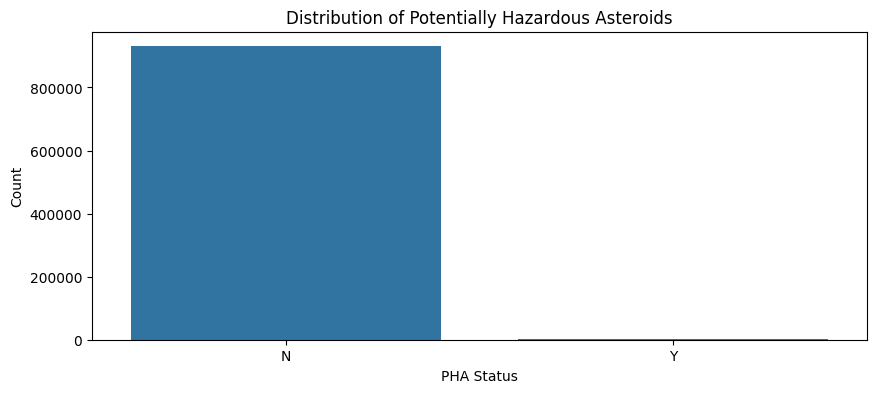

In [68]:
# Create chart for PHA distribution

plt.figure(figsize=(10,4))

sns.countplot(x='pha', data=df_selected)

plt.title('Distribution of Potentially Hazardous Asteroids')
plt.xlabel('PHA Status')
plt.ylabel('Count')

plt.show()

### Comment

The chart shows that most asteroids are classified as non-hazardous (`N`), while only a small number are classified as hazardous (`Y`). This confirms the strong class imbalance identified earlier in the statistical analysis.

## 20. Visualise Absolute Magnitude

This step creates a histogram for the `H` column, which represents asteroid absolute magnitude.

This is useful because absolute magnitude gives an idea of asteroid brightness. It can also indirectly relate to asteroid size, where lower `H` values usually mean brighter and potentially larger objects.

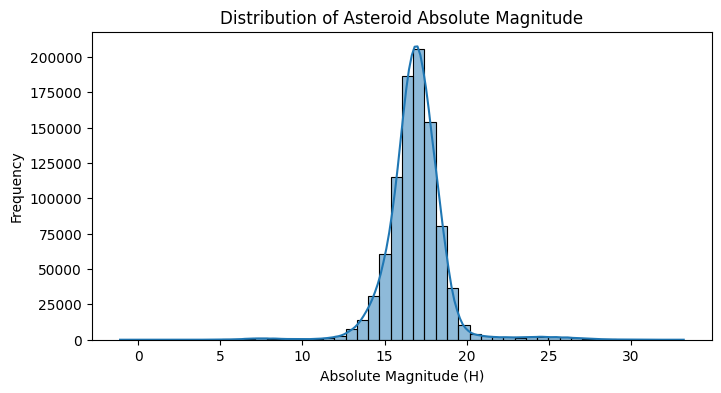

In [69]:
# Create histogram for asteroid absolute magnitude

plt.figure(figsize=(8,4))

sns.histplot(df_selected['H'], bins=50, kde=True)

plt.title('Distribution of Asteroid Absolute Magnitude')
plt.xlabel('Absolute Magnitude (H)')
plt.ylabel('Frequency')

plt.show()

### Comment

The histogram shows that most asteroid absolute magnitude values are concentrated between approximately 14 and 19. This means most asteroids in the dataset have similar brightness levels.

The chart also shows a small number of asteroids with much lower or higher magnitude values, which may represent unusually bright or dim asteroids. The distribution is not perfectly symmetrical, indicating some variation and possible outliers in the dataset.

## 21. Detect Outliers Using a Boxplot

This step creates a boxplot for asteroid absolute magnitude (`H`) to identify possible outliers.

A boxplot is useful because it shows the spread of the data, the middle range of values, and any extreme values that are far from the rest of the dataset.

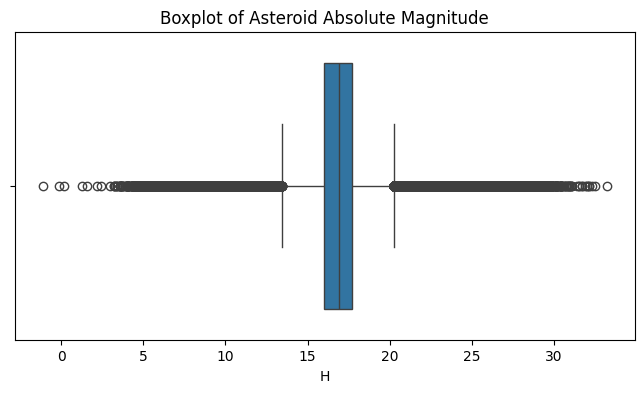

In [70]:
# Create boxplot for asteroid absolute magnitude

plt.figure(figsize=(8,4))

sns.boxplot(x=df_selected['H'])

plt.title('Boxplot of Asteroid Absolute Magnitude')

plt.show()

### Comment

The boxplot shows that most asteroid absolute magnitude values are grouped within a relatively small range around the centre of the dataset. However, several values appear far outside the main range, which indicates the presence of outliers.

These outliers may represent unusually bright or unusually dim asteroids compared with the majority of objects in the dataset. Identifying outliers is important because extreme values can affect statistical analysis and machine learning performance.

## 22. Create Correlation Heatmap

This step creates a correlation heatmap for the selected numerical features.

A correlation heatmap is useful because it shows how strongly features are related to each other. This can help identify which variables may be useful for analysis and machine learning.

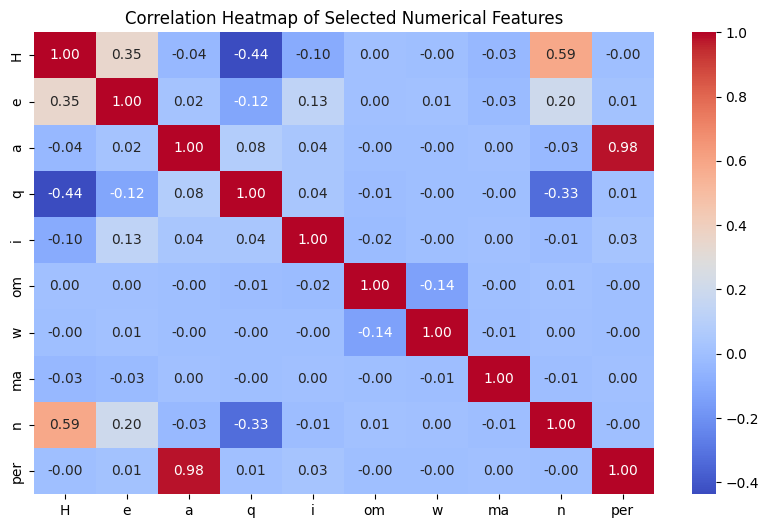

In [71]:
# Create correlation heatmap for numerical features

numeric_features = df_selected.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))

sns.heatmap(numeric_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Selected Numerical Features')

plt.show()

### Comment

The heatmap shows the strength of relationships between the numerical asteroid features. Red colours represent stronger positive relationships, blue colours represent negative relationships, and values close to 0 show weak relationships.

One of the strongest positive correlations appears between `a` (semi-major axis) and `per` (orbital period), with a value close to 0.98. This means asteroids with larger orbital distances usually have longer orbital periods.

The heatmap also shows some moderate negative relationships, such as between `H` and `q`. Most other features have weak correlations, meaning they do not strongly move together.

This analysis is useful because it helps identify which features may influence each other and which variables may be important for the machine learning model.

## 23. Compare Hazardous and Non-Hazardous Asteroids

This step compares the absolute magnitude (`H`) of hazardous and non-hazardous asteroids.

This helps identify whether hazardous asteroids show different magnitude patterns compared with non-hazardous asteroids.

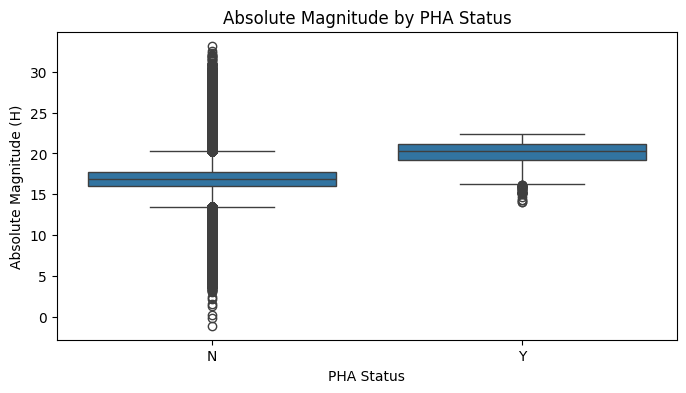

In [72]:
# Compare absolute magnitude by PHA status

plt.figure(figsize=(8,4))

sns.boxplot(x='pha', y='H', data=df_selected)

plt.title('Absolute Magnitude by PHA Status')
plt.xlabel('PHA Status')
plt.ylabel('Absolute Magnitude (H)')

plt.show()

### Comment

The boxplot shows differences between hazardous (`Y`) and non-hazardous (`N`) asteroids in terms of absolute magnitude (`H`).

Hazardous asteroids generally appear within a narrower magnitude range, while non-hazardous asteroids show a much wider spread of values and more outliers.

The median magnitude for hazardous asteroids is also slightly higher than for non-hazardous asteroids. This suggests that absolute magnitude may have some relationship with whether an asteroid is classified as potentially hazardous.

## 24. Compare Orbital Eccentricity by PHA Status

This step compares orbital eccentricity (`e`) for hazardous and non-hazardous asteroids.

Eccentricity shows how stretched an asteroid orbit is. A value closer to 0 means the orbit is more circular, while a value closer to 1 means the orbit is more stretched.

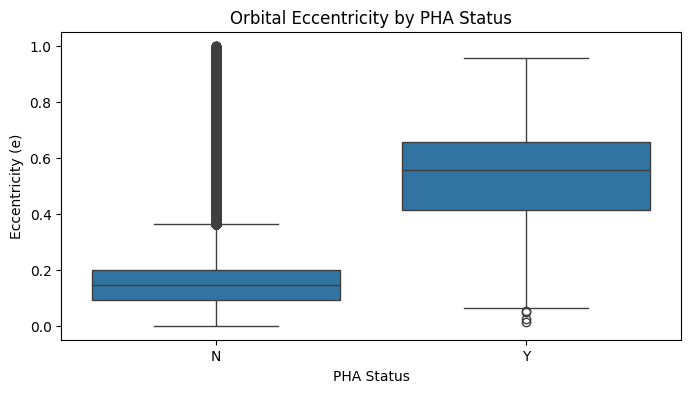

In [73]:
# Compare orbital eccentricity by PHA status

plt.figure(figsize=(8,4))

sns.boxplot(x='pha', y='e', data=df_selected)

plt.title('Orbital Eccentricity by PHA Status')
plt.xlabel('PHA Status')
plt.ylabel('Eccentricity (e)')

plt.show()

### Comment

The boxplot shows a noticeable difference in orbital eccentricity between hazardous (`Y`) and non-hazardous (`N`) asteroids.

Hazardous asteroids generally have higher eccentricity values, meaning their orbits are more stretched or elongated. Non-hazardous asteroids are mostly grouped around lower eccentricity values, which suggests more circular or stable orbits.

This indicates that orbital eccentricity may be an important feature for identifying potentially hazardous asteroids in the classification model.

## 25. Scatter Plot of Semi-Major Axis and Eccentricity

This step creates a scatter plot comparing semi-major axis (`a`) and orbital eccentricity (`e`).

This visualisation helps identify patterns, clusters, and relationships between asteroid orbital distance and orbit shape.

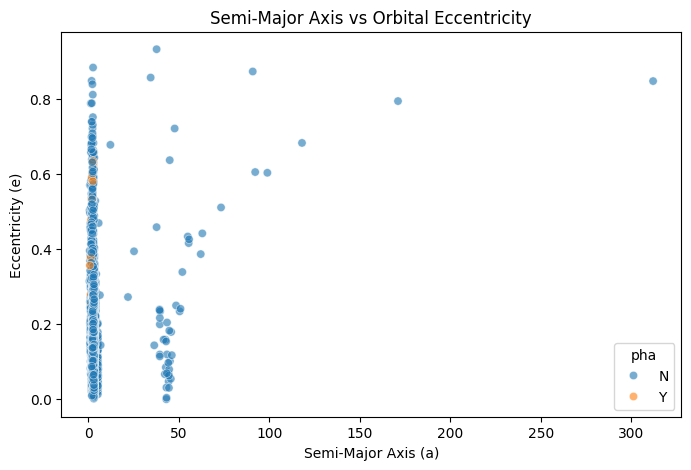

In [74]:
# Create scatter plot for semi-major axis and eccentricity

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='a',
    y='e',
    hue='pha',
    data=df_selected.sample(10000),  # Use sample for faster plotting
    alpha=0.6
)

plt.title('Semi-Major Axis vs Orbital Eccentricity')
plt.xlabel('Semi-Major Axis (a)')
plt.ylabel('Eccentricity (e)')

plt.show()

### Comment

The scatter plot shows the relationship between semi-major axis (`a`) and orbital eccentricity (`e`) for both hazardous and non-hazardous asteroids. Most asteroids are clustered at lower semi-major axis values, while only a smaller number appear at very large orbital distances.

The plot also shows that hazardous asteroids (`Y`) are mixed within the same general regions as non-hazardous asteroids (`N`), meaning there is no single clear separation between the two classes using only these two features.

This visualisation is useful because it helps identify clusters, spread, and unusual orbital patterns in the asteroid dataset. It also demonstrates that machine learning is needed to analyse multiple features together rather than relying on a single orbital measurement.

# Part 2 — Machine Learning and Asteroid Classification

This section focuses on building and evaluating a machine learning classification model to predict whether an asteroid is potentially hazardous (`PHA`) or non-hazardous.

The cleaned dataset and selected features will now be prepared for machine learning. The process will include data preparation, model training, prediction, and evaluation using metrics such as accuracy, precision, recall, F1-score, and confusion matrix.

## 26. Prepare Data for Machine Learning

This step prepares the dataset for machine learning classification.

Machine learning models require input features (`X`) and a target variable (`y`). The selected asteroid features will be used as input data, while the `pha` column will be used as the target variable for prediction.

In [75]:
# Prepare features and target variable

X = df_selected.drop('pha', axis=1)

y = df_selected['pha']

# Display feature and target shapes

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (932335, 11)
Target shape: (932335,)


### Comment

The dataset has been successfully separated into input features (`X`) and the target variable (`y`).

The feature dataset contains 932,335 asteroid records with 11 selected features, while the target dataset contains the corresponding hazardous asteroid classifications. This structure is required before training a machine learning model.

## 27. Encode Categorical Variables

This step converts categorical text values into numerical values.

Machine learning models work with numerical data, so columns such as `neo` and `pha` must be encoded into numbers before the model can be trained.

In [76]:
# Convert categorical values into numerical values

df_selected['neo'] = df_selected['neo'].map({'N': 0, 'Y': 1})

df_selected['pha'] = df_selected['pha'].map({'N': 0, 'Y': 1})

# Display first rows after encoding

df_selected.head()

,neo,H,e,a,q,i,om,w,ma,n,per,pha
0,0,3.40,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,0.213885,1683.145703,0
1,0,4.20,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,0.213345,1687.410992,0
2,0,5.33,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,0.226129,1592.013769,0
3,0,3.00,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,0.271609,1325.432763,0
4,0,6.90,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,0.238661,1508.414421,0


### Comment

The categorical values were converted into numerical form. Non-hazardous (`N`) and hazardous (`Y`) values are now represented using 0 and 1, which makes the dataset compatible with machine learning algorithms.

## 28. Recreate Features and Target After Encoding

This step recreates the input features and target variable after converting text values into numbers.

This is needed because the machine learning model should use the encoded numerical version of the dataset.

In [77]:
# Recreate features and target after encoding

X = df_selected.drop('pha', axis=1)

y = df_selected['pha']

# Display first rows

X.head()

,neo,H,e,a,q,i,om,w,ma,n,per
0,0,3.40,0.076009,2.769165,2.558684,10.594067,80.305531,73.597695,77.372098,0.213885,1683.145703
1,0,4.20,0.229972,2.773841,2.135935,34.832932,173.024741,310.202392,144.975675,0.213345,1687.410992
2,0,5.33,0.256936,2.668285,1.982706,12.991043,169.851482,248.066193,125.435355,0.226129,1592.013769
3,0,3.00,0.088721,2.361418,2.151909,7.141771,103.810804,150.728541,95.861938,0.271609,1325.432763
4,0,6.90,0.190913,2.574037,2.082619,5.367427,141.571026,358.648418,17.846343,0.238661,1508.414421


### Comment

The features (`X`) and target variable (`y`) were recreated after encoding the categorical values into numbers. The dataset is now fully numerical, which means it can be understood and processed correctly by machine learning algorithms.

The input features now contain asteroid orbital and measurement data, while the target variable contains the final hazardous asteroid classification using binary values (`0` = non-hazardous, `1` = hazardous).

## 29. Split Data into Training and Testing Sets

This step splits the dataset into training data and testing data.

The training data is used to teach the machine learning model. The testing data is used to check how well the model performs on new data it has not seen before.

In this project, 80% of the data is used for training and 20% is used for testing.

In [78]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shape of each dataset

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (745868, 11)
X_test shape: (186467, 11)
y_train shape: (745868,)
y_test shape: (186467,)


## 30. Train the Machine Learning Model

This step trains a machine learning classification model using the training dataset.

A Random Forest Classifier is used because it is effective for classification problems and can handle large datasets with multiple features. The model will learn patterns from asteroid measurements and orbital characteristics to predict whether an asteroid is potentially hazardous.

In [79]:
# Import Random Forest Classifier

from sklearn.ensemble import RandomForestClassifier


# Create the machine learning model

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# Train the model

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Comment

The Random Forest classification model was successfully trained using the training dataset.

During training, the model learned relationships between asteroid orbital measurements and the hazardous asteroid classification. Random Forest works by creating multiple decision trees and combining their results to improve prediction accuracy and reduce overfitting.

The trained model is now ready to make predictions using unseen asteroid data from the testing dataset.

## 31. Make Predictions Using the Model

This step uses the trained machine learning model to predict hazardous asteroid classifications using the testing dataset.

The predictions will later be compared with the real values to evaluate how accurately the model performs.

In [80]:
# Make predictions using the testing dataset

y_pred = model.predict(X_test)

# Display first predictions

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### Comment

The trained Random Forest model generated predictions for the testing dataset. The displayed values represent the predicted asteroid classifications, where `0` means non-hazardous and `1` means hazardous.

The first predictions are mostly `0`, which reflects the strong class imbalance found earlier in the dataset. Since most asteroids are non-hazardous, the model naturally predicts many non-hazardous cases.

This demonstrates why accuracy alone may not be sufficient for evaluating the model performance. Additional evaluation metrics such as precision, recall, F1-score, and confusion matrix will be important in the next steps.

## 32. Evaluate Model Accuracy

This step evaluates the prediction accuracy of the machine learning model.

Accuracy measures how many predictions were classified correctly compared with the total number of predictions made by the model.

In [81]:
# Import accuracy score

from sklearn.metrics import accuracy_score


# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9985037566968954


### Comment

The Random Forest model achieved an accuracy score of approximately 99.85%, which means most asteroid classifications were predicted correctly.

However, this result should be interpreted carefully because the dataset is highly imbalanced. Most asteroids in the dataset are non-hazardous, so the model can achieve very high accuracy by predicting mainly non-hazardous cases.

For this reason, additional evaluation metrics such as precision, recall, F1-score, and confusion matrix are required to better understand how well the model identifies hazardous asteroids.

## 33. Generate Classification Report

This step generates a classification report for the machine learning model.

The report includes precision, recall, F1-score, and support values for both hazardous and non-hazardous asteroid classes.

These metrics provide a more detailed evaluation of the model performance than accuracy alone.

In [82]:
# Import classification report

from sklearn.metrics import classification_report


# Generate classification report

report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    186054
           1       0.75      0.48      0.59       413

    accuracy                           1.00    186467
   macro avg       0.88      0.74      0.79    186467
weighted avg       1.00      1.00      1.00    186467



### Comment

The classification report provides a more detailed evaluation of the machine learning model performance.

For class `0` (non-hazardous asteroids), the model achieved almost perfect precision, recall, and F1-score. This means the model was very successful at identifying non-hazardous asteroids.

For class `1` (hazardous asteroids), the precision score was 0.75, which means that 75% of asteroids predicted as hazardous were actually hazardous. However, the recall score was lower at 0.48, meaning the model only identified around 48% of all real hazardous asteroids.

The F1-score for hazardous asteroids was 0.59, showing moderate performance for the minority class. This result demonstrates the effect of class imbalance in the dataset, where hazardous asteroids are much rarer than non-hazardous asteroids.

Although the overall accuracy is very high, the classification report shows that the model still struggles to detect all hazardous asteroids correctly.

## 34. Create Confusion Matrix

This step creates a confusion matrix to visualise the machine learning model predictions.

A confusion matrix shows how many predictions were classified correctly and incorrectly. It helps identify true positives, true negatives, false positives, and false negatives.

This provides a clearer understanding of model performance, especially for imbalanced datasets.

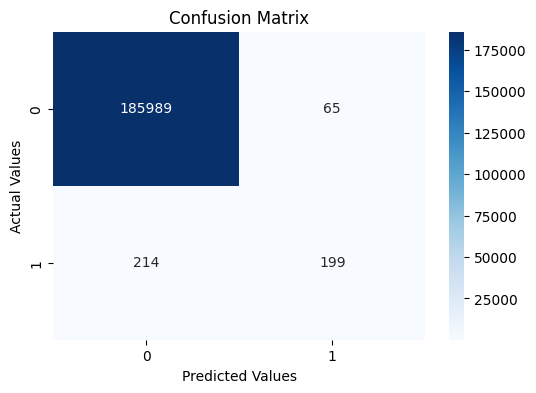

In [83]:
# Import confusion matrix tools

from sklearn.metrics import confusion_matrix

# Create confusion matrix

cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix as heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')

plt.show()

### Comment

The confusion matrix shows that the machine learning model performed very well when identifying non-hazardous asteroids.

- 185,989 non-hazardous asteroids were correctly classified.
- 199 hazardous asteroids were correctly identified.
- 65 safe asteroids were incorrectly predicted as hazardous.
- 214 hazardous asteroids were missed and incorrectly predicted as safe.

The model shows very high overall accuracy, but the confusion matrix also confirms that detecting hazardous asteroids is more difficult because they represent a very small part of the dataset.

This result supports the earlier observation about class imbalance and explains why recall and F1-score are important evaluation metrics for this project.

## 35. Feature Importance Analysis

This step checks which features had the most influence on the Random Forest model.

Feature importance is useful because it helps explain which asteroid characteristics contributed most to the model predictions.

In [84]:
# Check feature importance from the Random Forest model

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
1,H,0.240244
4,q,0.159230
5,i,0.127813
7,w,0.097282
2,e,0.091355
8,ma,0.055921
3,a,0.053305
9,n,0.051259
10,per,0.051161
6,om,0.048256


### Comment

The feature importance analysis shows which asteroid characteristics had the strongest influence on the machine learning model predictions.

The most important feature was `H` (absolute magnitude), followed by orbital features such as `q`, `i`, `w`, and `e`.

This suggests that asteroid brightness and orbital characteristics play an important role in identifying potentially hazardous asteroids.

Some features, such as `neo`, had lower importance values, meaning they contributed less to the final predictions.

This analysis helps improve understanding of how the Random Forest model makes classification decisions.

## 36. Visualise Feature Importance

This step creates a bar chart showing the importance of each feature in the Random Forest model.

This makes it easier to see which asteroid features had the strongest influence on the model predictions.

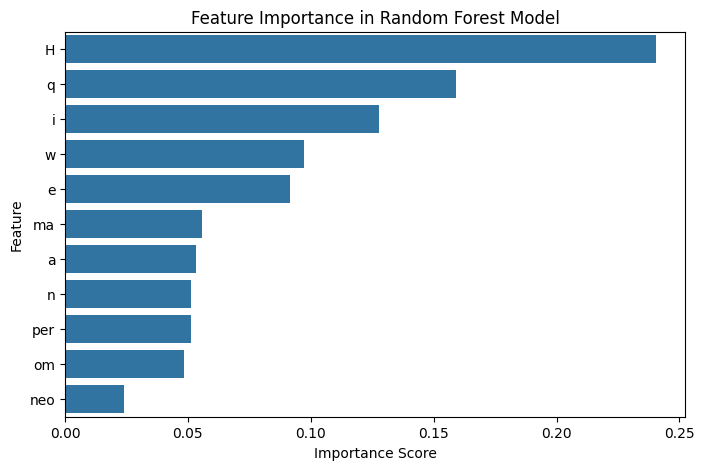

In [85]:
# Visualise feature importance

plt.figure(figsize=(8,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

# PART 3 — Conclusion and Final Findings

## 37. Final Findings Summary

This section summarises the most important findings discovered during the exploratory data analysis and machine learning stages of the project.

### 
Key FindingsThis is an astronomical dataset consisting of astronomical as well as orbital elements containing large amount of data which is suitable for big data Analytics.



There are large number of columns which has too much missing values so we need to clean that before starting with any machine learning work.



This is a skewed dataset because of this there are more number of non-hazardous than hazardous.



After doing exploratory data analysis there is some visible differences among the hazardous and non-hazardous asteroids for some of the features like absolute magnitude and orbital eccentricity.



Random forest classifier shows that the overall accuracy is really very high when we classify the asteroids.



The results shows that the hazardous asteroid classification has more difficulty as the metrics are not showing the accuracy in hazardous asteroid class but because of that only the overall accuracy is high because the data is skewed towards non-hazardous class.



We got a feature importance ranking which gives us to understand which features are more influencing in our model like we see absolute magnitude (H) has high feature importance and orbital features like q, i, and e are also among the important features.



In our project we applied big data analytics on an asteroid dataset to perform analysis on it for asteroid classification to help in planetary defence.

## 38. Project Conclusion

in this project, we effectively utilized Big Data Analytics and machine learning to examine asteroid data and classify dangerous asteroids. We pre-processed the dataset, dealt with missing values, conducted data exploration and visualization, selected features, and performed machine learning-based classification using a Random Forest classifier. We established that we can employ machine learning algorithms to identify and extract patterns in asteroid data, particularly when dealing with orbital elements and magnitude data. We were able to create a model that has very good accuracy.

However, we also observed in the case study of imbalanced datasets that the performance of the model has to be carefully evaluated using metrics such as precision, recall, F1-score, and the confusion matrix. We concluded that we should not just rely on accuracy to validate the performance of our model.

In conclusion, the project gave an opportunity to learn about and work on a real life dataset related to the study of asteroids and planets, and demonstrate how Python, data analytics, and machine learning can be used to contribute to scientific discovery and planetary defence.

## 39. Project Limitations

The results generated are quite strong, however there were several limitations encountered throughout the course of this project.





The dataset included quite a few null values which meant that some columns as well as rows were discarded.



The dataset was not balanced; this is because hazardous asteroids are only represented by a very small percentage of the data.



Only one algorithm from machine learning was used.



Some astronomical parameters should be explained in more detail from a scientific perspective.



Historical data of datasets from the dataset was utilized, but no real-time tracking of asteroid activity was conducted.





## 40. Future Improvements

Several improvements could be made in future work.

For one, the dataset could be improved by applying other machine learning models such as Logistic Regression, Decision Trees or XGBoost. Furthermore, techniques such as SMOTE or oversampling could be used to improve the performance of the detection of hazardous asteroids for the imbalanced dataset.

In the future, the dataset may also be enhanced through more advanced feature engineering to get more predictive power. Furthermore, we could integrate real-time NASA asteroid data API to get the live analysis. Lastly, the model could be upgraded by using the deep learning model to accomplish a better performance with more complicated classification.

## 41. Final Reflection

This project offered practical experience in Big Data Analytics and Machine Learning using Python.

Key skills in data cleaning, missing value treatment, data visualisation, feature analysis, and machine learning classification were refined over the course of the project. The project increased confidence when dealing with large data sets and using libraries such as Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn.

The main take away from this project was that accuracy is not everything. When dealing with an imbalanced data set, very high accuracy is not necessarily indicative of a high-quality model. The evaluation metrics and confusion matrix showed a much clearer picture of the models actual performance.

In conclusion, this project offered valuable practical knowledge and experience and illustrated that Machine Learning can be applied to real-world scientific/planetary defence problems.



